# 0. At a glance: the results in euros

The other notebooks derive each result with the full method and its caveats. This one restates
the main results as concrete euro examples, in plain language. All amounts are in euros; "today's
money" means adjusted for inflation.

**Terms used below**

| Term | Meaning | Example |
|---|---|---|
| Volatility | How much the value typically swings in a year | 12 %: in about two years out of three, the return lands within 12 points of its average |
| Drawdown | Fall from the previous high | 10,000 falling to 4,750 is a 52 % drawdown |
| Correlation | Whether two assets move together | +1 always together, 0 unrelated, -1 always opposite |
| Monte Carlo | Replaying thousands of possible market histories | 10,000 simulated 30-year histories built from real months |
| Standard deviation (sigma) | The typical size of a move | a "5-sigma day" is a move five times larger than a typical day |

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import montecarlo as mc
from investor_toolkit import proxies, universe
from investor_toolkit import returns as rt
from investor_toolkit.plotting import INK, INK_MUTED, INK_SECONDARY, SERIES
from investor_toolkit.tax import MIXED_FUND, GermanTax

long = proxies.long_history()
balanced = 0.6 * long["world_equity"] + 0.4 * long["bund_10y"]

## 1. One savings plan, 100 possible futures

Save 500 per month for 30 years in a 60/40 portfolio (world equity and German government bonds),
with 0.2 % fund costs and German tax. That is 180,000 paid in. The simulation replays 10,000
histories assembled from real months since 1999. Each dot below is one of 100 representative
outcomes (every percentile), so "6 dots" means "6 in 100".

paid in                           180000.0
worst of 100                      128671.0
5th of 100                        172544.0
median                            319723.0
95th of 100                       555636.0
best of 100                       754436.0
futures below paid in (of 100)         6.0
dtype: float64

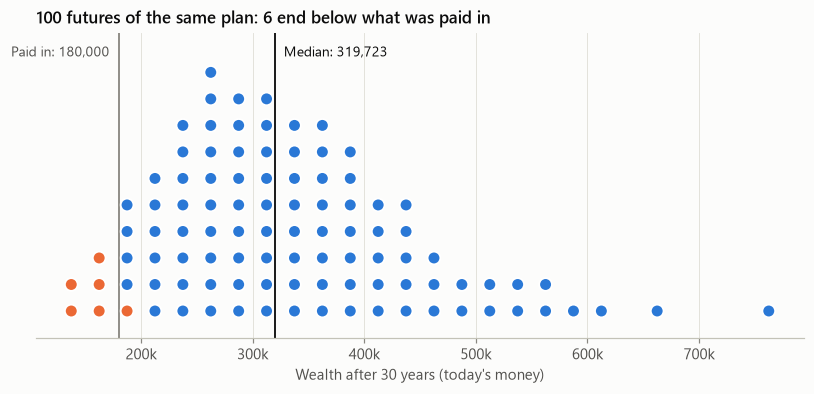

In [2]:
plan = mc.SavingsPlan(
    monthly_contribution=500,
    accumulation_years=30,
    annual_fee=0.002,
    tax=GermanTax(partial_exemption=MIXED_FUND),
)
result = mc.simulate(
    mc.Bootstrap(balanced, long["inflation"], mean_block=12), plan, n_paths=10_000, seed=1
)
final = result.wealth_at_retirement()  # today's money, before selling
futures = np.quantile(final, (np.arange(100) + 0.5) / 100)
invested = 500 * 12 * 30

bin_width = 25_000
bins = np.floor(futures / bin_width).astype(int)
heights = np.zeros_like(bins)
for i, b in enumerate(bins):
    heights[i] = np.sum(bins[:i] == b)
below = futures < invested

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.scatter(
    (bins + 0.5) * bin_width,
    heights + 1,
    s=70,
    color=np.where(below, SERIES[1], SERIES[0]),
    edgecolor="white",
    linewidth=1.2,
    zorder=3,
)
ax.axvline(invested, color=INK_MUTED, linewidth=1.2)
ax.axvline(np.median(final), color=INK, linewidth=1.2)
ax.annotate(
    f"Paid in: {invested:,.0f}",
    (invested, heights.max() + 1.6),
    xytext=(-6, 0),
    textcoords="offset points",
    ha="right",
    color=INK_SECONDARY,
    fontsize=9,
)
ax.annotate(
    f"Median: {np.median(final):,.0f}",
    (np.median(final), heights.max() + 1.6),
    xytext=(6, 0),
    textcoords="offset points",
    color=INK,
    fontsize=9,
)
ax.set_ylim(0, heights.max() + 2.5)
ax.set_yticks([])
ax.grid(axis="y", visible=False)
ax.spines["left"].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v / 1000:,.0f}k"))
ax.set_xlabel("Wealth after 30 years (today's money)")
ax.set_title(f"100 futures of the same plan: {below.sum()} end below what was paid in")
fig.savefig(f"{FIGURES}/glance_futures.png")

pd.Series(
    {
        "paid in": invested,
        "worst of 100": futures[0],
        "5th of 100": futures[4],
        "median": np.median(final),
        "95th of 100": futures[94],
        "best of 100": futures[-1],
        "futures below paid in (of 100)": int(below.sum()),
    }
).round(0)

The plan most likely ends with about 1.8 times the money paid in, after inflation. But the
spread is wide: the luckiest futures end with several times what the unluckiest do, and a few
end below the amount paid in once inflation is accounted for.

## 2. A real crash, in euros

10,000 invested in world equities at the August 2000 peak (euros, dividends reinvested, no costs):

Lowest value 4,751 in March 2003; back above 10,000 after 150 months; 50,613 by August 2026


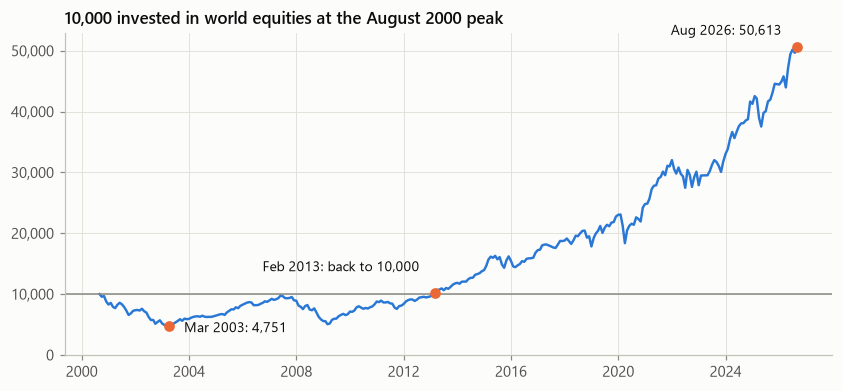

In [3]:
growth = (1 + long["world_equity"]).cumprod()
peak = growth.loc[:"2001"].idxmax()
value = 10_000 * growth.loc[peak:] / growth[peak]
trough = value.loc[:"2004"].idxmin()
recovered = value.loc[trough:][value.loc[trough:] >= 10_000].index[0]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(value.index, value, color=SERIES[0])
ax.axhline(10_000, color=INK_MUTED, linewidth=1.0)
for date, label, offset in [
    (trough, f"{trough:%b %Y}: {value[trough]:,.0f}", (10, -4)),
    (recovered, f"{recovered:%b %Y}: back to 10,000", (-10, 14)),
    (value.index[-1], f"{value.index[-1]:%b %Y}: {value.iloc[-1]:,.0f}", (-10, 8)),
]:
    ax.plot(date, value[date], "o", color=SERIES[1], markersize=6, zorder=3)
    ax.annotate(
        label,
        (date, value[date]),
        xytext=offset,
        textcoords="offset points",
        ha="left" if offset[0] > 0 else "right",
        fontsize=9,
        color=INK,
    )
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylim(bottom=0)
ax.set_title("10,000 invested in world equities at the August 2000 peak")
fig.savefig(f"{FIGURES}/glance_crash.png")
months_under = (recovered.year - peak.year) * 12 + recovered.month - peak.month
print(
    f"Lowest value {value[trough]:,.0f} in {trough:%B %Y}; "
    f"back above 10,000 after {months_under} months; "
    f"{value.iloc[-1]:,.0f} by {value.index[-1]:%B %Y}"
)

The loss was temporary, but "temporary" meant 12 years. Whoever had to sell in 2003 lost half;
whoever could wait was rewarded. This is why the time horizon matters more than the average return.

## 3. Extreme days are not rare

How often did the MSCI World ETF move by more than 3, 4 or 5 typical daily moves since 2010,
compared with what a normal (bell-curve) model predicts?

In [4]:
prices = universe.load_asset_prices(["EUNL.DE"])["EUNL.DE"].dropna()
daily = rt.simple_returns(prices).loc["2009-12-31":]
years = len(daily) / 252
tails = rt.tail_frequencies(daily, thresholds=(3.0, 4.0, 5.0))
pd.DataFrame(
    {
        "days it happened": tails["observed"].astype(int),
        "normal model expects": tails["expected_normal"].round(2),
        "normal model: once every ... years": (years / tails["expected_normal"]).round(0),
    }
).rename_axis(f"move larger than (in {years:.0f} years of data)")

,days it happened,normal model expects,normal model: once every ... years
move larger than (in 17 years of data),,,
3 sigma,72,11.49,1.0
4 sigma,24,0.27,63.0
5 sigma,10,0.00,6922.0


A bell-curve model says a 5-sigma day should happen roughly once in several thousand years of
trading. It happened ten times in seventeen years. Risk models built on the normal distribution
underestimate how often markets crash.

## 4. Do bonds protect you when stocks fall?

,World equity,10-year Bund
date,,
2002,-0.296,0.111
2008,-0.375,0.147
2022,-0.129,-0.223


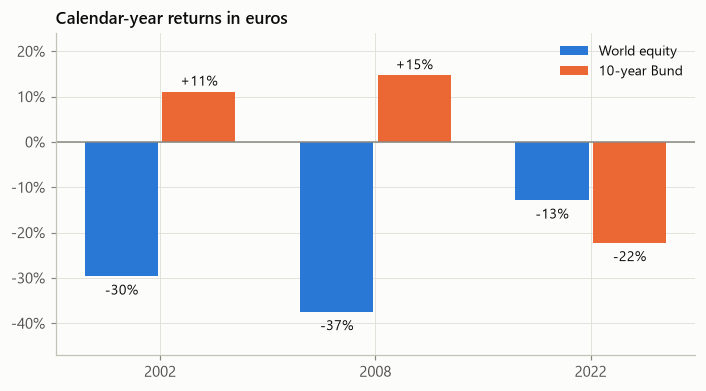

In [5]:
calendar = (1 + long[["world_equity", "bund_10y"]]).groupby(long.index.year).prod() - 1
years_shown = [2002, 2008, 2022]
table = calendar.loc[years_shown].rename(
    columns={"world_equity": "World equity", "bund_10y": "10-year Bund"}
)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
x = np.arange(len(years_shown))
for i, (column, color) in enumerate(zip(table.columns, SERIES[:2], strict=True)):
    bars = ax.bar(x + (i - 0.5) * 0.36, table[column], width=0.34, color=color, label=column)
    for bar, v in zip(bars, table[column], strict=True):
        ax.annotate(
            f"{v:+.0%}",
            (bar.get_x() + bar.get_width() / 2, v),
            xytext=(0, 4 if v > 0 else -12),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color=INK,
        )
ax.axhline(0, color=INK_MUTED, linewidth=1.0)
ax.set_xticks(x, [str(y) for y in years_shown])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(-0.47, 0.24)
ax.set_title("Calendar-year returns in euros")
ax.legend(loc="upper right")
fig.savefig(f"{FIGURES}/glance_bonds.png")
table.round(3)

In 2002 and 2008, German government bonds rose while stocks crashed, so a 60/40 portfolio lost
far less than stocks alone. In 2022, when inflation drove interest rates up, both fell together.
The hedge works against recessions, not against inflation.

## 5. Spreading the risk

One German stock (average)    0.265
Five German stocks            0.195
World index (MSCI World)      0.124
dtype: float64

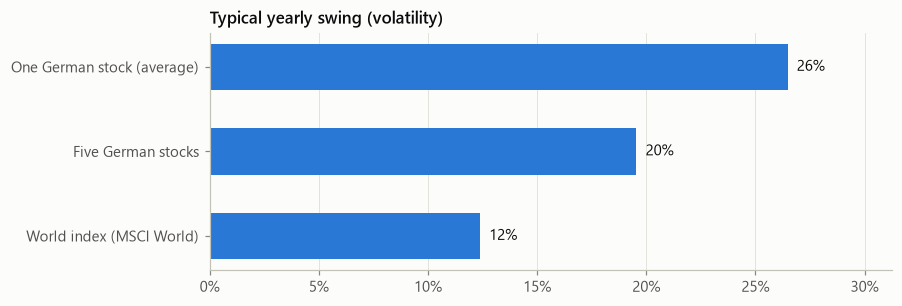

In [6]:
returns = universe.load_asset_returns()
stocks = returns[universe.MODEL_PORTFOLIOS["concentrated"].tickers]
vols = pd.Series(
    {
        "One German stock (average)": (stocks.std() * np.sqrt(12)).mean(),
        "Five German stocks": stocks.mean(axis=1).std() * np.sqrt(12),
        "World index (MSCI World)": returns["EUNL.DE"].std() * np.sqrt(12),
    }
)
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(vols.index[::-1], vols.to_numpy()[::-1], color=SERIES[0], height=0.55)
for i, v in enumerate(vols.to_numpy()[::-1]):
    ax.annotate(
        f"{v:.0%}",
        (v, i),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        color=INK,
    )
ax.set_xlim(0, vols.max() * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_title("Typical yearly swing (volatility)")
fig.savefig(f"{FIGURES}/glance_diversification.png")
vols.round(3)

Going from one stock to five cuts the typical swing by about a quarter; going to the whole world
cuts it by more than half. The five German stocks still move together (same economy), which is
why adding more of the *same kind* stops helping.

## 6. How much can a retiree withdraw?

Retire with 500,000 in a 60/40 portfolio and withdraw a fixed amount every year, raised with
inflation, for 30 years. Each square is one of 100 simulated histories.

4%    0.838
3%    0.967
Name: share of histories that last 30 years, dtype: float64

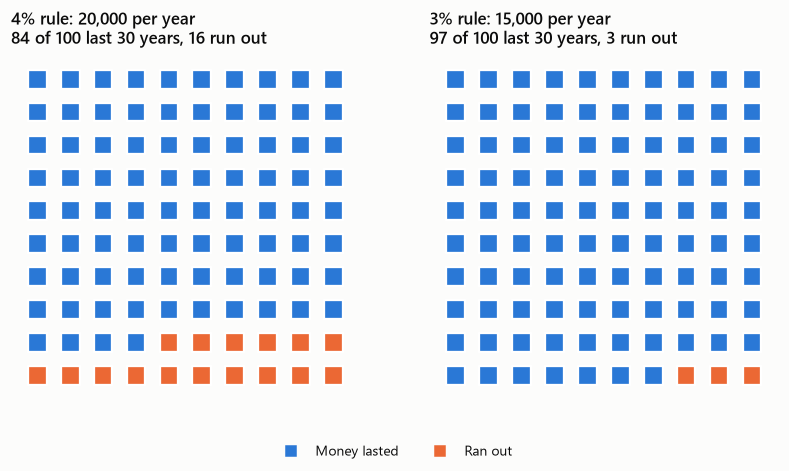

In [7]:
model = mc.Bootstrap(balanced, long["inflation"], mean_block=12)
outcomes = {}
for rate in (0.04, 0.03):
    p = mc.SavingsPlan(
        initial=500_000,
        monthly_contribution=0,
        accumulation_years=0,
        withdrawal_years=30,
        withdrawal_rate=rate,
        annual_fee=0.002,
    )
    outcomes[rate] = mc.simulate(model, p, n_paths=10_000, seed=2).success_rate()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4))
for ax, (rate, success) in zip(axes, outcomes.items(), strict=True):
    lasted = round(success * 100)
    colors = [SERIES[0]] * lasted + [SERIES[1]] * (100 - lasted)
    xs, ys = np.meshgrid(np.arange(10), np.arange(10)[::-1])
    ax.scatter(
        xs.ravel(), ys.ravel(), s=150, marker="s", color=colors, edgecolor="white", linewidth=1.5
    )
    ax.set_xlim(-0.8, 9.8)
    ax.set_ylim(-0.8, 9.8)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        f"{rate:.0%} rule: {500_000 * rate:,.0f} per year\n"
        f"{lasted} of 100 last 30 years, {100 - lasted} run out"
    )
fig.legend(
    handles=[
        plt.Line2D([], [], marker="s", linestyle="", color=SERIES[0], label="Money lasted"),
        plt.Line2D([], [], marker="s", linestyle="", color=SERIES[1], label="Ran out"),
    ],
    loc="lower center",
    ncols=2,
)
fig.savefig(f"{FIGURES}/glance_withdrawals.png")
pd.Series(
    {f"{r:.0%}": s for r, s in outcomes.items()}, name="share of histories that last 30 years"
)

The popular "4 % rule" comes from US data. With euro-area returns since 1999 it failed in roughly
one history out of six; withdrawing 3 % failed in only a few. The difference of 5,000 per year
is the price of sleeping well. See notebook 7 for allocations and horizons.

## Where each number comes from

| Result | Notebook |
|---|---|
| 100 futures, withdrawals | [7. Monte Carlo](07_montecarlo.ipynb) |
| Crash and recovery | [3. Risk](03_risk.ipynb) |
| Extreme days | [2. Returns](02_returns.ipynb) |
| Bonds as protection, spreading risk | [4. Diversification](04_diversification.ipynb) |
| How the simulations are checked | [8. Validation](08_validation.ipynb) |